In [1]:
# Simple MLP Model for ERA5 Wave Spectra (with all directional moments)
import numpy as np
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Load processed data
data_path = "data\processed"
arrays = []

# Load all processed files
for file in os.listdir(data_path):
    print(f"Processing file: {file}")
    full_path = os.path.join(data_path, file)
    print(f"Loading {file}")
    data = np.load(full_path, allow_pickle=False)
    print(f"  Keys: {list(data.keys())}")
    print(f"  X shape: {data['X'].shape}")
    print(f"  y shape: {data['y'].shape}")
    arrays.append(data)

# Combine all samples
total_samples = sum(len(arr['X']) for arr in arrays)
print(f"Total samples: {total_samples}")

# Initialize arrays for combined data
combined_X = []
combined_y = []

for arr in arrays:
    combined_X.append(arr['X'])
    combined_y.append(arr['y'])

# Convert to numpy arrays and extract features
X_combined = np.concatenate(combined_X, axis=0)  # Shape: (samples, 5, 30)
y_combined = np.concatenate(combined_y, axis=0)  # Shape: (samples, 30, 24)

# Extract ALL components from X (use ALL 5 components: S1D, a1, b1, a2, b2)
S1D = X_combined[:, 0, :]  # 1D spectra: (samples, 30)
a1 = X_combined[:, 1, :]   # Directional moment a1: (samples, 30)  
b1 = X_combined[:, 2, :]   # Directional moment b1: (samples, 30)
a2 = X_combined[:, 3, :]   # Directional moment a2: (samples, 30) - INCLUDED
b2 = X_combined[:, 4, :]   # Directional moment b2: (samples, 30) - INCLUDED
S2D = y_combined           # 2D spectra: (samples, 30, 24)

print(f"Data shapes:")
print(f"S1D: {S1D.shape}")  
print(f"S2D: {S2D.shape}")
print(f"a1: {a1.shape}")
print(f"b1: {b1.shape}")
print(f"a2: {a2.shape}")   # NEW
print(f"b2: {b2.shape}")   # NEW

# Check for any NaN values in loaded data
print(f"NaN values in S1D: {np.isnan(S1D).sum()}")
print(f"NaN values in S2D: {np.isnan(S2D).sum()}")
print(f"NaN values in a1: {np.isnan(a1).sum()}")
print(f"NaN values in b1: {np.isnan(b1).sum()}")
print(f"NaN values in a2: {np.isnan(a2).sum()}")  # NEW
print(f"NaN values in b2: {np.isnan(b2).sum()}")  # NEW

Processing file: era5_wave_training.npz
Loading era5_wave_training.npz
  Keys: ['X', 'y', 'freq_hz', 'direction_deg', 'valid_time']
  X shape: (9504, 5, 30)
  y shape: (9504, 30, 24)
Total samples: 9504
Data shapes:
S1D: (9504, 30)
S2D: (9504, 30, 24)
a1: (9504, 30)
b1: (9504, 30)
a2: (9504, 30)
b2: (9504, 30)
NaN values in S1D: 0
NaN values in S2D: 0
NaN values in a1: 0
NaN values in b1: 0
NaN values in a2: 0
NaN values in b2: 0


<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_14724\615587787.py:2: SyntaxWarning: invalid escape sequence '\p'
  data_path = "data\processed"


In [3]:
# Prepare inputs for MLP model (ALL moments - no baseline needed)
print("Preparing inputs for MLP model...")

# Create model inputs by concatenating ALL features
# Input features: S1D (30) + a1 (30) + b1 (30) + a2 (30) + b2 (30) = 150 features
batch_size, n_freq, n_dir = S2D.shape
n_features = n_freq * 5  # ALL 5 components

# Flatten and concatenate ALL inputs
inputs = np.concatenate([
    S1D.reshape(batch_size, -1),  # Shape: (batch_size, 30)  
    a1.reshape(batch_size, -1),   # Shape: (batch_size, 30)
    b1.reshape(batch_size, -1),   # Shape: (batch_size, 30)
    a2.reshape(batch_size, -1),   # Shape: (batch_size, 30) - NEW
    b2.reshape(batch_size, -1)    # Shape: (batch_size, 30) - NEW
], axis=1)  # Final shape: (batch_size, 150)

# Target is the FULL 2D spectrum (NOT residuals - direct regression)
targets = S2D.reshape(batch_size, -1)  # Shape: (batch_size, 30*24=720)

print(f"Input shape: {inputs.shape}")
print(f"Target shape: {targets.shape}")
print(f"Input features: {n_features} (S1D + a1 + b1 + a2 + b2)")

# Check for any remaining NaN values
nan_inputs = np.isnan(inputs).sum()
nan_targets = np.isnan(targets).sum()
print(f"NaN in inputs: {nan_inputs}")
print(f"NaN in targets: {nan_targets}")

if nan_inputs > 0 or nan_targets > 0:
    print("WARNING: NaN values detected! Will clean...")
    # Find rows with any NaN
    input_mask = ~np.isnan(inputs).any(axis=1)
    target_mask = ~np.isnan(targets).any(axis=1)
    valid_mask = input_mask & target_mask
    
    print(f"Valid samples: {valid_mask.sum()}/{len(valid_mask)}")
    
    # Filter out NaN samples
    inputs = inputs[valid_mask]
    targets = targets[valid_mask]
    S2D = S2D[valid_mask]
    print(f"Cleaned input shape: {inputs.shape}")
    print(f"Cleaned target shape: {targets.shape}")

# Basic statistics
print(f"Input range: [{inputs.min():.6f}, {inputs.max():.6f}]")
print(f"Target range: [{targets.min():.6f}, {targets.max():.6f}]")
print(f"Input mean: {inputs.mean():.6f}, std: {inputs.std():.6f}")
print(f"Target mean: {targets.mean():.6f}, std: {targets.std():.6f}")

Preparing inputs for MLP model...
Input shape: (9504, 150)
Target shape: (9504, 720)
Input features: 150 (S1D + a1 + b1 + a2 + b2)
NaN in inputs: 0
NaN in targets: 0
Input range: [-0.991445, 22.504860]
Target range: [0.000000, 19.814178]
Input mean: -0.121308, std: 0.506509
Target mean: 0.025833, std: 0.173907


In [4]:
# Normalize inputs and split data
print("Normalizing inputs and splitting data...")

# Normalize inputs to improve training stability
input_mean = inputs.mean(axis=0, keepdims=True)
input_std = inputs.std(axis=0, keepdims=True) + 1e-8  # Add small epsilon for numerical stability
inputs_norm = (inputs - input_mean) / input_std

# Save normalization parameters for later evaluation (proper deployment practice)
os.makedirs("models", exist_ok=True)
np.savez("models/mlp_normalization.npz", input_mean=input_mean, input_std=input_std)
print(f"💾 Saved normalization parameters to models/mlp_normalization.npz")

# For targets, use raw 2D spectrum without scaling
targets_norm = targets
target_scale = 1.0  # No scaling applied

print(f"Input normalization - Mean: {input_mean.mean():.6f}, Std: {input_std.mean():.6f}")
print(f"Target scaling factor: {target_scale:.6f}")
print(f"Normalized input range: [{inputs_norm.min():.6f}, {inputs_norm.max():.6f}]")
print(f"Normalized target range: [{targets_norm.min():.6f}, {targets_norm.max():.6f}]")

# Split data chronologically (proper for time-series wave data)
n_samples = len(inputs_norm)
n_train = int(0.7 * n_samples)
n_val = int(0.15 * n_samples)
n_test = n_samples - n_train - n_val

# Don't shuffle - preserve temporal structure
indices = np.arange(n_samples)  # Chronological order
train_idx = indices[:n_train]
val_idx = indices[n_train:n_train+n_val]
test_idx = indices[n_train+n_val:]

# Create splits
X_train, y_train = inputs_norm[train_idx], targets_norm[train_idx]
X_val, y_val = inputs_norm[val_idx], targets_norm[val_idx]
X_test, y_test = inputs_norm[test_idx], targets_norm[test_idx]

# Split 2D spectra for evaluation
S2D_train = S2D[train_idx]
S2D_val = S2D[val_idx]
S2D_test = S2D[test_idx]

print(f"Data splits:")
print(f"Train: {X_train.shape[0]} samples")
print(f"Val: {X_val.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

# Convert to PyTorch tensors
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
X_val_t = torch.FloatTensor(X_val).to(device)
y_val_t = torch.FloatTensor(y_val).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)

Normalizing inputs and splitting data...
💾 Saved normalization parameters to models/mlp_normalization.npz
Input normalization - Mean: -0.121308, Std: 0.339513
Target scaling factor: 1.000000
Normalized input range: [-8.264766, 23.587287]
Normalized target range: [0.000000, 19.814178]
Data splits:
Train: 6652 samples
Val: 1425 samples
Test: 1427 samples
Using device: cpu


In [5]:
# Define simple MLP architecture (no physics components)
class SimpleMLP(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size, dropout_rate=0.2):
        super(SimpleMLP, self).__init__()
        self.input_size = input_size
        self.output_size = output_size
        
        # Build layers
        layers = []
        prev_size = input_size
        
        # Hidden layers
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.Dropout(dropout_rate))
            prev_size = hidden_size
        
        # Output layer (no activation for regression)
        layers.append(nn.Linear(prev_size, output_size))
        
        # Combine into sequential model
        self.network = nn.Sequential(*layers)
        
        # Initialize weights
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                # Xavier initialization 
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    
    def forward(self, x):
        return self.network(x)



In [6]:
# Create model
input_size = X_train.shape[1]   # 150 features (S1D + a1 + b1 + a2 + b2)
hidden_sizes = [512, 512, 256]  # 3 hidden layers
output_size = y_train.shape[1]  # 720 outputs (30 freq × 24 dir)

model = SimpleMLP(input_size, hidden_sizes, output_size).to(device)

print(f"Simple MLP model created:")
print(f"Input size: {input_size} (S1D + a1 + b1 + a2 + b2)")
print(f"Hidden layers: {hidden_sizes}")  
print(f"Output size: {output_size} (30 freq × 24 dir)")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")

# Test forward pass with small batch to check for issues
test_batch = X_train_t[:4]  # Small test batch
with torch.no_grad():
    test_output = model(test_batch)
    print(f"Test output shape: {test_output.shape}")
    print(f"Test output range: [{test_output.min().item():.6f}, {test_output.max().item():.6f}]")
    print(f"Test output has NaN: {torch.isnan(test_output).any().item()}")

print("Simple MLP architecture defined successfully")

Simple MLP model created:
Input size: 150 (S1D + a1 + b1 + a2 + b2)
Hidden layers: [512, 512, 256]
Output size: 720 (30 freq × 24 dir)
Number of parameters: 658,896
Test output shape: torch.Size([4, 720])
Test output range: [-2.908826, 3.211251]
Test output has NaN: False
Simple MLP architecture defined successfully


In [7]:
# Define simple loss function (MSE only - no physics)
def simple_mse_loss(pred, target):
    """Simple MSE loss function"""
    return torch.mean((pred - target)**2)

# Training setup
print("Setting up training...")

# Training hyperparameters
learning_rate = 1e-4    # Conservative learning rate
batch_size = 32         # Batch size
num_epochs = 50         # Number of epochs
weight_decay = 1e-5     # L2 regularization

# Create data loaders
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(X_val_t, y_val_t)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Optimizer and scheduler
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.7, patience=5)

print(f"Training configuration:")
print(f"  Learning rate: {learning_rate}")
print(f"  Batch size: {batch_size}")
print(f"  Number of epochs: {num_epochs}")
print(f"  Weight decay: {weight_decay}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")

# Training history
train_losses = []
val_losses = []
best_val_loss = float('inf')

print("Ready to start simple MLP training")

Setting up training...


Training configuration:
  Learning rate: 0.0001
  Batch size: 32
  Number of epochs: 50
  Weight decay: 1e-05
  Train batches: 208
  Val batches: 45
Ready to start simple MLP training


In [8]:
# Simple MLP training loop
model_path = "models/mlp.pth"  # Path to save the best model

print("Starting simple MLP training...")

for epoch in range(num_epochs):
    # Training phase
    model.train()
    epoch_train_loss = 0.0
    train_batches = 0
    
    for batch_idx, (batch_x, batch_y) in enumerate(train_loader):
        optimizer.zero_grad()
        
        # Forward pass
        pred = model(batch_x)
        
        # Ensure non-negative predictions (wave spectra must be positive)
        pred = torch.clamp(pred, min=0.0)
        
        # Compute simple MSE loss
        loss = simple_mse_loss(pred, batch_y)
        
        # Check for NaN 
        if torch.isnan(loss):
            print(f"NaN loss detected at epoch {epoch+1}, batch {batch_idx+1}")
            print(f"  Pred range: [{pred.min().item():.6f}, {pred.max().item():.6f}]")
            break
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Check for NaN gradients
        grad_norms = [p.grad.norm().item() if p.grad is not None else 0 for p in model.parameters()]
        if any(np.isnan(gn) for gn in grad_norms):
            print(f"NaN gradients detected at epoch {epoch+1}, batch {batch_idx+1}")
            break
        
        optimizer.step()
        
        epoch_train_loss += loss.item()
        train_batches += 1
        
        # Print progress every 50 batches
        if (batch_idx + 1) % 50 == 0:
            print(f"  Batch {batch_idx+1}/{len(train_loader)}, Loss: {loss.item():.6f}")
    
    # Validation phase
    model.eval()
    epoch_val_loss = 0.0
    val_batches = 0
    
    with torch.no_grad():
        for batch_idx, (batch_x, batch_y) in enumerate(val_loader):
            # Forward pass
            pred = model(batch_x)
            
            # Ensure non-negative predictions
            pred = torch.clamp(pred, min=0.0)
            
            # Compute loss
            loss = simple_mse_loss(pred, batch_y)
            
            if not torch.isnan(loss):
                epoch_val_loss += loss.item()
                val_batches += 1
    
    # Average losses
    avg_train_loss = epoch_train_loss / max(train_batches, 1)
    avg_val_loss = epoch_val_loss / max(val_batches, 1)
    
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    
    # Print epoch summary
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {avg_train_loss:.6f}")
    print(f"  Val Loss: {avg_val_loss:.6f}")
    print(f"  Learning Rate: {optimizer.param_groups[0]['lr']:.2e}")
    
    # Learning rate scheduling
    scheduler.step(avg_val_loss)
    
    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), model_path)
        print(f"  New best MLP model saved (val_loss: {best_val_loss:.6f})")
    
    print("-" * 50)

print("Simple MLP training completed!")
print(f"Best validation loss: {best_val_loss:.6f}")

Starting simple MLP training...
  Batch 50/208, Loss: 0.274963
  Batch 100/208, Loss: 0.215471
  Batch 150/208, Loss: 0.216618
  Batch 200/208, Loss: 0.118078
Epoch 1/50
  Train Loss: 0.227383
  Val Loss: 0.057030
  Learning Rate: 1.00e-04
  New best MLP model saved (val_loss: 0.057030)
--------------------------------------------------
  Batch 50/208, Loss: 0.102782
  Batch 100/208, Loss: 0.070547
  Batch 150/208, Loss: 0.067573
  Batch 200/208, Loss: 0.060693
Epoch 2/50
  Train Loss: 0.092763
  Val Loss: 0.024902
  Learning Rate: 1.00e-04
  New best MLP model saved (val_loss: 0.024902)
--------------------------------------------------
  Batch 50/208, Loss: 0.059310
  Batch 100/208, Loss: 0.047690
  Batch 150/208, Loss: 0.041566
  Batch 200/208, Loss: 0.043443
Epoch 3/50
  Train Loss: 0.057954
  Val Loss: 0.019533
  Learning Rate: 1.00e-04
  New best MLP model saved (val_loss: 0.019533)
--------------------------------------------------
  Batch 50/208, Loss: 0.159897
  Batch 100/208,

In [9]:
# Simple MLP model evaluation 
print("Evaluating simple MLP model...")

# Load best model
model.load_state_dict(torch.load(model_path))
model.eval()

# Make predictions on test set
with torch.no_grad():
    test_predictions = model(X_test_t)
    
    # Ensure non-negative predictions
    test_predictions = torch.clamp(test_predictions, min=0.0)

# Convert back to numpy for evaluation
test_predictions_np = test_predictions.cpu().numpy()
test_target_np = S2D_test

# Reshape predictions back to 2D spectrum format
test_predictions_2d = test_predictions_np.reshape(len(test_predictions_np), n_freq, n_dir)

# Compute reconstruction errors
def compute_relative_error(pred, target):
    """Compute relative error with proper handling of small values"""
    # Add small epsilon to avoid division by zero
    epsilon = 1e-15
    target_safe = np.maximum(target, epsilon)
    
    # Relative error
    rel_error = np.abs(pred - target) / target_safe
    
    # Weight by spectral energy to focus on significant frequencies
    weights = target / (np.sum(target, axis=(1,2), keepdims=True) + epsilon)
    weighted_error = np.sum(weights * rel_error, axis=(1,2))
    
    return np.mean(weighted_error)

# MLP model error
mlp_error = compute_relative_error(test_predictions_2d, test_target_np)

# L2 norm error calculation
print("Computing L2 norm error...")

# Remove NaN values for error computation
y_true_clean = np.nan_to_num(test_target_np, nan=0.0)
y_pred_clean = np.nan_to_num(test_predictions_2d, nan=0.0)

# Relative L2 error per time step
epsilon_l2 = 1e-10  # avoid division by zero
n_time = len(test_target_np)

norm_true = np.linalg.norm(y_true_clean.reshape(n_time, -1), axis=1)
norm_diff = np.linalg.norm((y_pred_clean - y_true_clean).reshape(n_time, -1), axis=1)
relative_l2_error = norm_diff / (norm_true + epsilon_l2)
l2_mlp_error = np.mean(relative_l2_error)

print("\n" + "="*60)
print("SIMPLE MLP MODEL EVALUATION RESULTS")
print("="*60)
print("WEIGHTED ENERGY-BASED ERROR:")
print(f"MLP model error:                   {mlp_error:.6f}")

print("\nL2 NORM ERROR:")
print(f"MLP model L2 error:                {l2_mlp_error:.6f}")

# Additional statistics
print(f"\nDetailed statistics:")
print(f"Test set size:                     {len(test_target_np)} samples")
print(f"Mean target energy:                {np.mean(np.sum(test_target_np, axis=(1,2))):.6f}")
print(f"Mean MLP energy:                   {np.mean(np.sum(test_predictions_2d, axis=(1,2))):.6f}")

print(f"\nL2 error statistics:")
print(f"MLP L2 - Mean: {np.mean(relative_l2_error):.6f}, Std: {np.std(relative_l2_error):.6f}")
print(f"MLP L2 - Min: {np.min(relative_l2_error):.6f}, Max: {np.max(relative_l2_error):.6f}")

# Energy conservation check
energy_conservation = np.abs(
    np.mean(np.sum(test_predictions_2d, axis=(1,2))) - np.mean(np.sum(test_target_np, axis=(1,2)))
) / np.mean(np.sum(test_target_np, axis=(1,2)))

print(f"Energy conservation error:         {energy_conservation:.6f}")

print("="*60)

Evaluating simple MLP model...
Computing L2 norm error...

SIMPLE MLP MODEL EVALUATION RESULTS
WEIGHTED ENERGY-BASED ERROR:
MLP model error:                   0.645179

L2 NORM ERROR:
MLP model L2 error:                0.617989

Detailed statistics:
Test set size:                     1427 samples
Mean target energy:                27.796831
Mean MLP energy:                   18.516329

L2 error statistics:
MLP L2 - Mean: 0.617989, Std: 0.311822
MLP L2 - Min: 0.133831, Max: 2.396939
Energy conservation error:         0.333869


In [10]:
# R-squared (coefficient of determination) calculation for MLP
print("Computing R-squared values for MLP model...")

# Flatten the 2D spectra for R-squared calculation
y_true_flat = test_target_np.flatten()
y_pred_mlp_flat = test_predictions_2d.flatten()

# Calculate R-squared for MLP model
ss_res_mlp = np.sum((y_true_flat - y_pred_mlp_flat) ** 2)
ss_tot = np.sum((y_true_flat - np.mean(y_true_flat)) ** 2)
r2_mlp = 1 - (ss_res_mlp / ss_tot)

print("\n" + "="*40)
print("R-SQUARED ANALYSIS (MLP)")
print("="*40)
print(f"MLP Model R²:               {r2_mlp:.6f}")

# Interpretation
print(f"\nVariance explained:")
print(f"  MLP Model: {r2_mlp*100:.2f}% of total variance")

# Correlation coefficient
corr_mlp = np.corrcoef(y_true_flat, y_pred_mlp_flat)[0, 1]

print(f"\nPearson correlation:")
print(f"  MLP Model: {corr_mlp:.6f}")

print("="*40)

print(f"\nMLP MODEL SUMMARY:")
print(f"  Input: S1D + a1 + b1 + a2 + b2 → 150 features")
print(f"  Architecture: Simple MLP with {hidden_sizes} hidden units")
print(f"  Output: Direct 2D spectrum → 720 values")
print(f"  Loss: Simple MSE (no physics constraints)")
print(f"  Training: {num_epochs} epochs")
print(f"  Final Performance:")
print(f"    - Weighted Error: {mlp_error:.6f}")
print(f"    - L2 Error: {l2_mlp_error:.6f}")
print(f"    - R²: {r2_mlp:.6f} ({r2_mlp*100:.2f}% variance explained)")

print("\n✓ Simple MLP model evaluation completed!")

Computing R-squared values for MLP model...

R-SQUARED ANALYSIS (MLP)
MLP Model R²:               0.793596

Variance explained:
  MLP Model: 79.36% of total variance

Pearson correlation:
  MLP Model: 0.897838

MLP MODEL SUMMARY:
  Input: S1D + a1 + b1 + a2 + b2 → 150 features
  Architecture: Simple MLP with [512, 512, 256] hidden units
  Output: Direct 2D spectrum → 720 values
  Loss: Simple MSE (no physics constraints)
  Training: 50 epochs
  Final Performance:
    - Weighted Error: 0.645179
    - L2 Error: 0.617989
    - R²: 0.793596 (79.36% variance explained)

✓ Simple MLP model evaluation completed!


# 🌊 Evaluation on Independent Dataset

Evaluate the trained MLP model on completely separate evaluation data to verify generalization performance.

In [11]:
# Load evaluation dataset
print("Loading evaluation dataset...")

eval_data_path = "eval_data\\gum\\2019\\01\\processed_1\\era5_wave_eval.npz"

if not os.path.exists(eval_data_path):
    print(f"❌ Evaluation data not found: {eval_data_path}")
    print("Make sure to run process.py to create evaluation dataset first")
else:
    eval_data = np.load(eval_data_path)
    
    # Load evaluation data
    X_eval = eval_data["X"]          # (time, 5, 30) - [S1D, a1, b1, a2, b2]
    y_eval = eval_data["y"]          # (time, 30, 24) - True 2D spectrum
    freq_hz_eval = eval_data["freq_hz"]
    direction_deg_eval = eval_data["direction_deg"]
    
    print(f"✅ Evaluation data loaded successfully")
    print(f"  X_eval shape: {X_eval.shape}")
    print(f"  y_eval shape: {y_eval.shape}")
    print(f"  Time steps: {X_eval.shape[0]}")
    print(f"  Frequency bins: {len(freq_hz_eval)}")
    print(f"  Direction bins: {len(direction_deg_eval)}")
    
    # Extract components (same as training)
    S1D_eval = X_eval[:, 0, :]  # 1D spectrum: (time, 30)
    a1_eval = X_eval[:, 1, :]   # First harmonic a1: (time, 30)
    b1_eval = X_eval[:, 2, :]   # First harmonic b1: (time, 30)
    a2_eval = X_eval[:, 3, :]   # Second harmonic a2: (time, 30)
    b2_eval = X_eval[:, 4, :]   # Second harmonic b2: (time, 30)
    S2D_eval = y_eval           # 2D spectra: (time, 30, 24)
    
    print(f"  S1D_eval: {S1D_eval.shape}")
    print(f"  S2D_eval: {S2D_eval.shape}")
    
    # Check for NaN values
    print(f"  NaN values in X_eval: {np.isnan(X_eval).sum()}")
    print(f"  NaN values in y_eval: {np.isnan(y_eval).sum()}")

Loading evaluation dataset...
✅ Evaluation data loaded successfully
  X_eval shape: (744, 5, 30)
  y_eval shape: (744, 30, 24)
  Time steps: 744
  Frequency bins: 30
  Direction bins: 24
  S1D_eval: (744, 30)
  S2D_eval: (744, 30, 24)
  NaN values in X_eval: 0
  NaN values in y_eval: 0


In [12]:
# Preprocess evaluation data (same as training)
if 'X_eval' in locals():
    print("Preprocessing evaluation data...")
    
    # Prepare inputs exactly as in training
    batch_size_eval = S2D_eval.shape[0]
    
    # Create model inputs (concatenate ALL features)
    inputs_eval = np.concatenate([
        S1D_eval.reshape(batch_size_eval, -1),  # Shape: (batch_size, 30)  
        a1_eval.reshape(batch_size_eval, -1),   # Shape: (batch_size, 30)
        b1_eval.reshape(batch_size_eval, -1),   # Shape: (batch_size, 30)
        a2_eval.reshape(batch_size_eval, -1),   # Shape: (batch_size, 30)
        b2_eval.reshape(batch_size_eval, -1)    # Shape: (batch_size, 30)
    ], axis=1)  # Final shape: (batch_size, 150)
    
    # Target is the FULL 2D spectrum
    targets_eval = S2D_eval.reshape(batch_size_eval, -1)  # Shape: (batch_size, 720)
    
    print(f"  Input shape: {inputs_eval.shape}")
    print(f"  Target shape: {targets_eval.shape}")
    
    # Create model for evaluation
    input_size = 150               # S1D + a1 + b1 + a2 + b2 (30*5)
    hidden_sizes = [512, 512, 256] # 3 hidden layers
    output_size = 720              # 30 freq × 24 dir (30*24)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = SimpleMLP(input_size, hidden_sizes, output_size).to(device)
    model_path = "models/mlp.pth"
    
    print(f"✅ Model created for evaluation")
    
    # Apply SAME normalization as training (use saved parameters)
    normalization_path = "models/mlp_normalization.npz"
    
    if 'input_mean' not in locals() or 'input_std' not in locals():
        if os.path.exists(normalization_path):
            # Load saved normalization parameters (proper approach)
            print(f"  📂 Loading saved normalization parameters from {normalization_path}")
            norm_data = np.load(normalization_path)
            input_mean = norm_data['input_mean']
            input_std = norm_data['input_std']
            print(f"  ✅ Loaded normalization parameters")
        else:
            print(f"  ⚠️  Saved normalization not found at {normalization_path}")
            print(f"  🔧 Using evaluation data normalization (real-world approach)")
            
            # In real deployment: normalize based on evaluation data statistics
            # This is what you'd do if you didn't save training normalization
            input_mean = inputs_eval.mean(axis=0, keepdims=True)
            input_std = inputs_eval.std(axis=0, keepdims=True) + 1e-8
            
            print(f"  ✅ Computed normalization from {len(inputs_eval)} evaluation samples")
            print(f"  ℹ️  Note: This may differ from training normalization")
    
    inputs_eval_norm = (inputs_eval - input_mean) / input_std
    
    print(f"  Applied training normalization")
    print(f"  Normalized input range: [{inputs_eval_norm.min():.6f}, {inputs_eval_norm.max():.6f}]")
    
    # Convert to PyTorch tensor
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    X_eval_t = torch.FloatTensor(inputs_eval_norm).to(device)
    
    print(f"  Converted to PyTorch tensor: {X_eval_t.shape}")
    
else:
    print("❌ Evaluation data not loaded. Run previous cell first.")

Preprocessing evaluation data...
  Input shape: (744, 150)
  Target shape: (744, 720)
✅ Model created for evaluation
  Applied training normalization
  Normalized input range: [-6.025949, 39.649116]
  Converted to PyTorch tensor: torch.Size([744, 150])


In [13]:
# Model evaluation on evaluation dataset
if 'X_eval_t' in locals():
    print("Evaluating MLP model on evaluation dataset...")
    
    # Load trained model
    model.load_state_dict(torch.load(model_path))
    model.eval()
    
    # Make predictions
    with torch.no_grad():
        eval_predictions = model(X_eval_t)
        
        # Ensure non-negative predictions
        eval_predictions = torch.clamp(eval_predictions, min=0.0)
    
    # Convert back to numpy
    eval_predictions_np = eval_predictions.cpu().numpy()
    
    # Reshape predictions back to 2D spectrum format
    eval_predictions_2d = eval_predictions_np.reshape(len(eval_predictions_np), 30, 24)
    
    print(f"  Predictions shape: {eval_predictions_2d.shape}")
    print(f"  Predictions range: [{eval_predictions_2d.min():.6e}, {eval_predictions_2d.max():.6e}]")
    
    # Compute L2 error (same method as training evaluation)
    print("  Computing L2 norm error...")
    
    y_true_eval_clean = np.nan_to_num(S2D_eval, nan=0.0)
    y_pred_eval_clean = np.nan_to_num(eval_predictions_2d, nan=0.0)
    
    # Relative L2 error per time step
    epsilon_l2 = 1e-10
    n_time_eval = len(S2D_eval)
    
    norm_true_eval = np.linalg.norm(y_true_eval_clean.reshape(n_time_eval, -1), axis=1)
    norm_diff_eval = np.linalg.norm((y_pred_eval_clean - y_true_eval_clean).reshape(n_time_eval, -1), axis=1)
    relative_l2_error_eval = norm_diff_eval / (norm_true_eval + epsilon_l2)
    l2_eval_error = np.mean(relative_l2_error_eval)
    
    # Compute R-squared (same method as training evaluation)
    print("  Computing R-squared...")
    
    y_true_flat_eval = S2D_eval.flatten()
    y_pred_flat_eval = eval_predictions_2d.flatten()
    
    ss_res_eval = np.sum((y_true_flat_eval - y_pred_flat_eval) ** 2)
    ss_tot_eval = np.sum((y_true_flat_eval - np.mean(y_true_flat_eval)) ** 2)
    r2_eval = 1 - (ss_res_eval / ss_tot_eval)
    
    # Correlation coefficient
    corr_eval = np.corrcoef(y_true_flat_eval, y_pred_flat_eval)[0, 1]
    
    # Energy conservation check
    energy_conservation_eval = np.abs(
        np.mean(np.sum(eval_predictions_2d, axis=(1,2))) - np.mean(np.sum(S2D_eval, axis=(1,2)))
    ) / np.mean(np.sum(S2D_eval, axis=(1,2)))
    
    print("\n" + "="*60)
    print("MLP MODEL EVALUATION ON INDEPENDENT DATASET")
    print("="*60)
    print(f"Dataset size:                      {n_time_eval} time steps")
    print(f"L2 Error:                          {l2_eval_error:.6f}")
    print(f"R²:                                {r2_eval:.6f} ({r2_eval*100:.2f}% variance explained)")
    print(f"Correlation:                       {corr_eval:.6f}")
    print(f"Energy conservation error:         {energy_conservation_eval:.6f}")
    
    # Statistics
    print(f"\nL2 error statistics:")
    print(f"  Mean: {np.mean(relative_l2_error_eval):.6f}")
    print(f"  Std:  {np.std(relative_l2_error_eval):.6f}")
    print(f"  Min:  {np.min(relative_l2_error_eval):.6f}")
    print(f"  Max:  {np.max(relative_l2_error_eval):.6f}")
    
    print("="*60)
    print("✅ Model evaluation completed!")
    
else:
    print("❌ Evaluation data not preprocessed. Run previous cells first.")

Evaluating MLP model on evaluation dataset...
  Predictions shape: (744, 30, 24)
  Predictions range: [0.000000e+00, 1.334356e+01]
  Computing L2 norm error...
  Computing R-squared...

MLP MODEL EVALUATION ON INDEPENDENT DATASET
Dataset size:                      744 time steps
L2 Error:                          2.356164
R²:                                -0.563528 (-56.35% variance explained)
Correlation:                       0.394754
Energy conservation error:         0.035091

L2 error statistics:
  Mean: 2.356164
  Std:  4.651614
  Min:  0.458649
  Max:  41.560165
✅ Model evaluation completed!


Creating heatmap visualizations...
  Selected timestamps: [0, 186, 372, 558, 743]


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_14724\2612399435.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


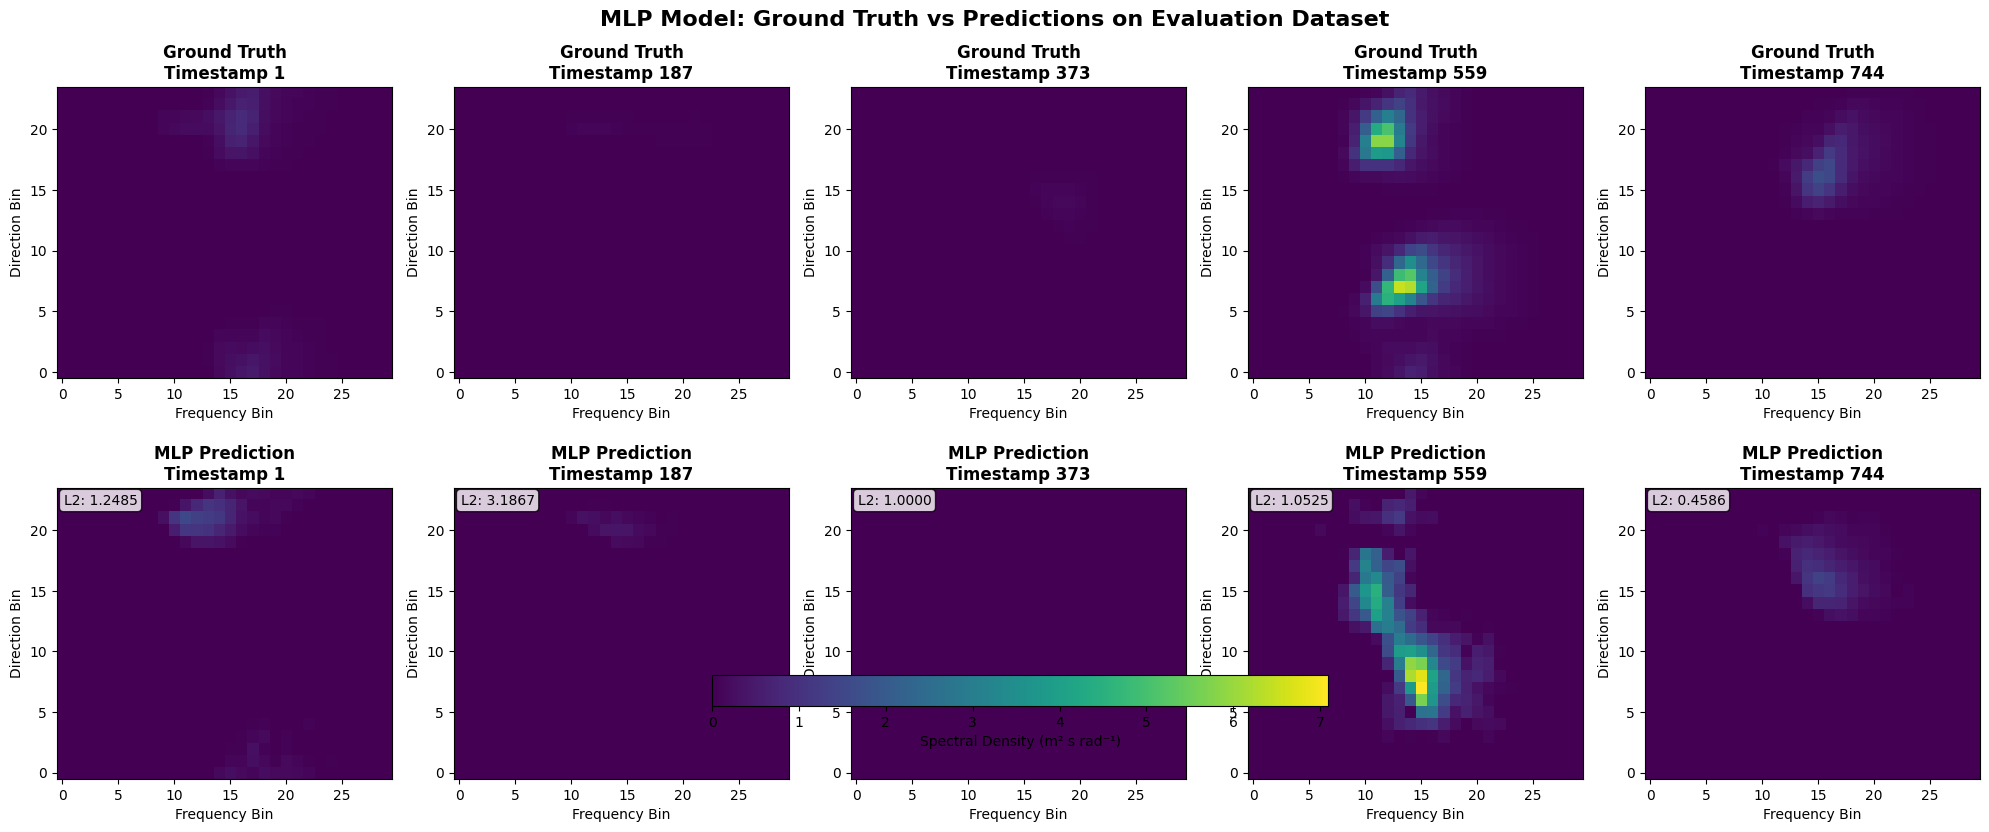


📊 Statistics for displayed timestamps:
  Timestamp 1: L2=1.2485, Energy error=0.0160
  Timestamp 187: L2=3.1867, Energy error=0.9312
  Timestamp 373: L2=1.0000, Energy error=1.0000
  Timestamp 559: L2=1.0525, Energy error=0.1077
  Timestamp 744: L2=0.4586, Energy error=0.1868

✅ Heatmap visualization completed!
   Overall L2 Error: 2.356164
   Overall R²: -0.563528


In [14]:
# Heatmap visualization: Ground Truth vs MLP Predictions
if 'eval_predictions_2d' in locals():
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    print("Creating heatmap visualizations...")
    
    # Select 5 representative timestamps
    n_timestamps = min(5, len(S2D_eval))
    # Spread across the dataset: first, quarter, middle, three-quarter, last
    if len(S2D_eval) > 1:
        indices = [
            0,                                    # First
            len(S2D_eval) // 4,                   # Quarter  
            len(S2D_eval) // 2,                   # Middle
            3 * len(S2D_eval) // 4,               # Three-quarter
            len(S2D_eval) - 1                     # Last
        ][:n_timestamps]
    else:
        indices = [0]
    
    print(f"  Selected timestamps: {indices}")
    
    # Set up plotting style
    plt.style.use('default')
    sns.set_palette("viridis")
    
    # Create comprehensive comparison plot
    fig, axes = plt.subplots(2, n_timestamps, figsize=(4*n_timestamps, 8))
    if n_timestamps == 1:
        axes = axes.reshape(-1, 1)
    
    # Global colorbar limits
    vmax = max(np.max(S2D_eval[indices]), np.max(eval_predictions_2d[indices]))
    vmin = 0
    
    for i, idx in enumerate(indices):
        # Ground truth (top row)
        im1 = axes[0, i].imshow(S2D_eval[idx].T, aspect='auto', cmap='viridis',
                               vmin=vmin, vmax=vmax, origin='lower')
        axes[0, i].set_title(f'Ground Truth\nTimestamp {idx+1}', fontsize=12, fontweight='bold')
        axes[0, i].set_xlabel('Frequency Bin')
        axes[0, i].set_ylabel('Direction Bin')
        
        # Model prediction (bottom row) 
        im2 = axes[1, i].imshow(eval_predictions_2d[idx].T, aspect='auto', cmap='viridis',
                               vmin=vmin, vmax=vmax, origin='lower')
        axes[1, i].set_title(f'MLP Prediction\nTimestamp {idx+1}', fontsize=12, fontweight='bold')
        axes[1, i].set_xlabel('Frequency Bin')
        axes[1, i].set_ylabel('Direction Bin')
        
        # Add error info
        ts_l2_error = relative_l2_error_eval[idx]
        axes[1, i].text(0.02, 0.98, f'L2: {ts_l2_error:.4f}', 
                       transform=axes[1, i].transAxes, fontsize=10,
                       verticalalignment='top', bbox=dict(boxstyle='round', 
                       facecolor='white', alpha=0.8))
    
    # Add colorbar
    fig.colorbar(im1, ax=axes, orientation='horizontal', fraction=0.05, pad=0.1,
                 label='Spectral Density (m² s rad⁻¹)')
    
    plt.suptitle('MLP Model: Ground Truth vs Predictions on Evaluation Dataset', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Summary statistics for displayed timestamps
    print(f"\n📊 Statistics for displayed timestamps:")
    for i, idx in enumerate(indices):
        gt_energy = np.sum(S2D_eval[idx])
        pred_energy = np.sum(eval_predictions_2d[idx])
        energy_error = abs(pred_energy - gt_energy) / gt_energy
        print(f"  Timestamp {idx+1}: L2={relative_l2_error_eval[idx]:.4f}, Energy error={energy_error:.4f}")
    
    print(f"\n✅ Heatmap visualization completed!")
    print(f"   Overall L2 Error: {l2_eval_error:.6f}")
    print(f"   Overall R²: {r2_eval:.6f}")
    
else:
    print("❌ Model predictions not available. Run previous cells first.")